In [2]:
import sympy as sp
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

In [130]:
# np.random.seed(14)
x_1, x_2, x_3 = sp.Symbol('x_1'), sp.Symbol('x_2'), sp.Symbol('x_3')
X = [x_1, x_2, x_3]
f = 5*x_1**2 + 2*x_2**2 + 5*x_3**2 - 2*x_1*x_2 - 4*x_1*x_3 - 2*x_3 + 1
l = 0.01
e = 0.00001 
x0 = np.array([0, 0, 0])
res = []
while True:
    x_rand_i = np.random.randint(0, len(X))
    x1 = x0 - l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) if i == x_rand_i else 0 for i in range(len(X))])
    print(l*np.array([sp.diff(f, X[i]).subs(dict(zip(X, x0))) if i == x_rand_i else 0  for i in range(len(X))]), sum([abs(_) for _ in (x1 - x0)]))
    res.append([x0, f.subs(dict(zip(X, x0)))])
    if sum([abs(_) for _ in (x1 - x0)]) < e and (f.subs(dict(zip(X, x1))) - f.subs(dict(zip(X, x0)))) < e:
        break
    x0 = x1
res

[0.0 0.0 -0.0200000000000000] 0.0200000000000000
[0.0 0.0 -0.0180000000000000] 0.0180000000000000
[-0.00152000000000000 0.0 0.0] 0.00152000000000000
[0.0 0.0 -0.0162608000000000] 0.0162608000000000
[-0.00201843200000000 0.0 0.0] 0.00201843200000000
[0.0 0.0 -0.0147154572800000] 0.0147154572800000
[0.0 -7.07686400000000e-5 0.0] 7.07686400000000e-5
[0.0 -6.79378944000000e-5 0.0] 6.79378944000000e-5
[-0.00240798122188800 0.0 0.0] 0.00240798122188800
[0.0 0.0 -0.0133402308008755] 0.0133402308008755
[0.0 -0.000113380003061760 0.0] 0.000113380003061760
[-0.00270305993179546 0.0 0.0] 0.00270305993179546
[0.0 0.0 -0.0121143301180598] 0.0121143301180598
[0.0 -0.000162906001575199 0.0] 0.000162906001575199
[0.0 0.0 -0.0109028971062538] 0.0109028971062538
[0.0 0.0 -0.00981260739562843] 0.00981260739562843
[-0.00374920544344510 0.0 0.0] 0.00374920544344510
[-0.00337428489910059 0.0 0.0] 0.00337428489910059
[-0.00303685640919053 0.0 0.0] 0.00303685640919053
[0.0 -0.000359596696546915 0.0] 0.0003595

[[array([0, 0, 0]), 1],
 [array([0.0, 0.0, 0.0200000000000000], dtype=object), 0.962000000000000],
 [array([0.0, 0.0, 0.0380000000000000], dtype=object), 0.931220000000000],
 [array([0.00152000000000000, 0.0, 0.0380000000000000], dtype=object),
  0.931000512000000],
 [array([0.00152000000000000, 0.0, 0.0542608000000000], dtype=object),
  0.905881218419200],
 [array([0.00353843200000000, 0.0, 0.0542608000000000], dtype=object),
  0.905494181984031],
 [array([0.00353843200000000, 0.0, 0.0689762572800000], dtype=object),
  0.884922437102878],
 [array([0.00353843200000000, 7.07686400000000e-5, 0.0689762572800000],
        dtype=object),
  0.884921946299238],
 [array([0.00353843200000000, 0.000138706534400000, 0.0689762572800000],
        dtype=object),
  0.884921493974603],
 [array([0.00594641322188800, 0.000138706534400000, 0.0689762572800000],
        dtype=object),
  0.884370648485932],
 [array([0.00594641322188800, 0.000138706534400000, 0.0823164880808755],
        dtype=object),
  0.8

In [19]:
np.random.seed(14)
np.random.randint(551)

344

In [ ]:
def stohastic_gradient_descent(X, 
    Y,
    /,
    error: float=0.001,
    itteration: int=1000,
    describe: bool=False,
    nround: int=3,
    convergence: bool=False,
    random_state: int=14 ) -> str:
    np.random.seed(random_state)
    X = np.array(X)
    Y = np.array(Y)
    W0 = sp.Symbol('w0')
    W = sp.symbols(f'w0:{0 if len(X.shape) == 1 else X.shape[1]+1}')
    variables = list(map(str, np.hstack(['w0', W])))
    w0 = np.zeros(0 if len(X.shape) == 1 else X.shape[1]+1, dtype=int) 
    res = []
    i = 0
    while True:
        k = np.random.randint(X.shape[0])
        f = (W0+X[k]@W-Y[k])**2
        H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
        S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
        t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
        w1 = w0 - t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])
        res.append([[round(_, nround) for _ in w0], f.subs(dict(zip(variables, w0)))])
        if describe:
            print(f'Иттерация №{i} с шагом {t} в точке приближения {dict(zip(W, res[-1][0]))} со значением {f.subs(dict(zip(W, w0)))} и погрешностью {abs(sum(w1 - w0))}')
        if abs(sum(w1 - w0)) < error:
            if convergence:
                sns.pointplot(x=range(i+1), y=[float(_[1]) for _ in res])
                plt.grid()
            return f'Приблеженные значения точки минимума: {dict(zip(variables, res[-1][0]))} со значением {res[-1][1]}, с точностью {error}'
        w0 = w1
        i += 1
        if i > itteration:
            return f'Число иттераций превысило {itteration}'

In [193]:
df = pd.read_csv('D:/ProjectPython/Анализ даных/Пакеты прикладных программ/FOOD-DATA-GROUP1 (1).csv').loc[:, 'Caloric Value':'Monounsaturated Fats']
df

,Caloric Value,Fat,Saturated Fats,Monounsaturated Fats
0,51,5.0,2.900,1.300
1,215,19.4,10.900,4.900
2,49,3.6,2.300,0.900
3,30,2.0,1.300,0.500
4,30,2.3,1.400,0.600
...,...,...,...,...
546,159,5.9,1.300,2.800
547,50,3.4,0.500,1.600
548,33,0.3,0.049,0.006
549,147,1.3,0.300,0.400


In [203]:
stohastic_gradient_descent(df.loc[:, 'Caloric Value':'Saturated Fats'], np.array(df['Monounsaturated Fats']), describe=True)

ValueError: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 4 is different from 3)

In [209]:
X = np.array(df.loc[:, 'Caloric Value':'Saturated Fats'])
Y = np.array(df['Monounsaturated Fats'])
W0 = sp.Symbol('w0')
W = sp.symbols(f'w0:{X.shape()[1]}')
W
# k = np.random.randint(X.shape[0])
# f = (W0+X[k]@W-Y[k])**2
# w0 = np.zeros(X.shape[1]+1, dtype=int)
# variables = list(map(str, np.hstack(['w0', W])))
# H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
# S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
# t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
# f, W,w0 , t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])


TypeError: 'tuple' object is not callable

In [31]:
X[1]@W

215.0*w1 + 19.4*w2 + 10.9*w3

In [138]:
X.shape

(551, 3)

In [200]:
((4,)[0], 0)

(4, 0)

In [33]:
Y[1]

np.float64(4.9)

In [35]:
(X[1]@W - Y[1])**2

(215.0*w1 + 19.4*w2 + 10.9*w3 - 4.9)**2

In [123]:
X_test = np.linspace(1, 100)
Y_test = 3 + 6*X_test + np.random.normal(0,1)
Y_test

array([  8.19247755,  20.31492653,  32.43737551,  44.55982449,
        56.68227347,  68.80472245,  80.92717143,  93.04962041,
       105.17206939, 117.29451837, 129.41696735, 141.53941633,
       153.66186531, 165.78431429, 177.90676327, 190.02921225,
       202.15166123, 214.2741102 , 226.39655918, 238.51900816,
       250.64145714, 262.76390612, 274.8863551 , 287.00880408,
       299.13125306, 311.25370204, 323.37615102, 335.4986    ,
       347.62104898, 359.74349796, 371.86594694, 383.98839592,
       396.1108449 , 408.23329388, 420.35574286, 432.47819184,
       444.60064082, 456.7230898 , 468.84553878, 480.96798776,
       493.09043674, 505.21288571, 517.33533469, 529.45778367,
       541.58023265, 553.70268163, 565.82513061, 577.94757959,
       590.07002857, 602.19247755])

<Axes: >

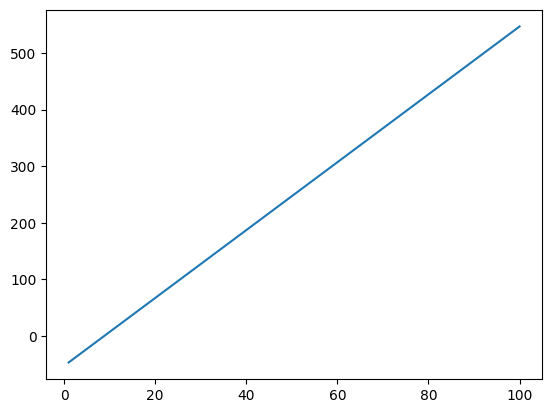

In [122]:
sns.lineplot(x=X_test, y=Y_test)

In [187]:
stohastic_gradient_descent(X_test, Y_test)

TypeError: unsupported operand type(s) for @: 'numpy.float64' and 'tuple'

In [139]:
X_test.shape

(50,)

In [202]:
np.random.seed(14)
X = X_test
Y = Y_test
W0 = sp.Symbol('w0')
W = sp.symbols(f'w1:{2 if len(X.shape) == 1 else X.shape[1]+1}')
k = np.random.randint(X.shape[0])
np.array(X[k]).reshape(1, -1) @ np.array(W).reshape(-1, 1)
f = (W0+X[k].reshape(1, -1)@W-Y[k])**2
w0 = np.zeros(0 if len(X.shape) == 1 else X.shape[1]+1, dtype=int)
variables = list(map(str, np.hstack(['w0', W])))
H = [[sp.diff(sp.diff(f, W[i]), W[j]).subs(dict(zip(W, w0))) for i in range(len(W))] for j in range(len(W))]
# S = np.array([sp.diff(f, W[i]).subs(dict(zip(variables, w0))) for i in range(len(W))])
# t = float(S@(S.T)/(S@H@(S.T)).subs(dict(zip(W, w0))))
# f, W,w0 , t*np.array([sp.diff(f, variables[i]).subs(dict(zip(variables, w0))) for i in range(len(variables))])

ValueError: 
Can't calculate derivative wrt (w0 + 87.8775510204081*w1 -
529.457783674151)**2.